# Flood Depth Distribution Analysis for Paper Figures

This notebook extracts maximum flood depth values within the Cypress Park polygon, prepares a cell-level dataset for plotting, and generates publication-ready distribution figures for current and future scenarios.

**Main outputs**
- Long-format table of raster-cell flood depths
- Professional violin + box plots
- Optional figure export for manuscript use

**Notes**
- Cells outside the polygon and NoData cells are excluded
- Flooded cells are defined as depth > 0.001 ft
- CRS consistency is assumed to have been verified before this workflow


## 1. Import libraries

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: set a clean plotting theme
sns.set_theme(style="whitegrid", context="talk")

## 2. Define input paths and analysis settings

In [2]:
# Input paths
raster_folder = r"E:\01. Project_deliverable\GIS\Flood_modeling_results\raster"
polygon_path = r"E:\01. Project_deliverable\GIS\Planning and Cadastre\Cypress_Park_boundaries\Cypress_Park_boundaries.shp"

# Output folder
output_folder = r"E:\01. Project_deliverable\GIS\Flood_modeling_results\paper_figures"
os.makedirs(output_folder, exist_ok=True)

# Flooded-cell threshold (ft)
DEPTH_THRESHOLD_FT = 0.001

# Scenario label mapping
name_mapping = {
    "base_2y_proc.tif": "Base - 2 Year",
    "base_10yr_proc.tif": "Base - 10 Year",
    "base_100yr_proc.tif": "Base - 100 Year",
    "future2070_2yr_proc.tif": "Future 2070 - 2 Year",
    "future2070_10yr_proc.tif": "Future 2070 - 10 Year",
    "future2070_100yr_proc.tif": "Future 2070 - 100 Year",
}

# Order used in tables and plots
plot_order = [
    "Base - 2 Year",
    "Base - 10 Year",
    "Base - 100 Year",
    "Future 2070 - 2 Year",
    "Future 2070 - 10 Year",
    "Future 2070 - 100 Year",
]

## 3. Read the polygon boundary

In [3]:
# Read polygon using Fiona to avoid pyogrio/PROJ issues
polygon_gdf = gpd.read_file(polygon_path, engine="fiona")
polygon_geom = [polygon_gdf.geometry.unary_union]

print("Polygon CRS:")
print(polygon_gdf.crs)
print("\nNumber of polygon features:", len(polygon_gdf))

Polygon CRS:
None

Number of polygon features: 1


c:\Users\dveronez\AppData\Local\anaconda3\envs\general\Lib\site-packages\geopandas\array.py:334: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  self.crs = crs
c:\Users\dveronez\AppData\Local\anaconda3\envs\general\Lib\site-packages\geopandas\geodataframe.py:59: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions depending on CRS will raise an error or may produce unexpected results.
  data.array.crs = crs
c:\Users\dveronez\AppData\Local\anaconda3\envs\general\Lib\site-packages\geopandas\geodataframe.py:407: UserWarning: Cannot set the CRS, falling back to None. The CRS support requires the 'pyproj' package, but it is not installed or does not import correctly. The functions de

## 4. Extract raster-cell flood depth values within the polygon

In [4]:
raster_files = sorted(glob.glob(os.path.join(raster_folder, "*.tif")))

all_values = []
raster_names = []

for raster_fp in raster_files:
    with rasterio.open(raster_fp) as src:
        # Mask raster to polygon; filled=False preserves masked values correctly
        out_image, out_transform = mask(
            src,
            polygon_geom,
            crop=True,
            filled=False
        )

        # Extract band 1 and remove masked pixels
        data = out_image[0]
        valid = data.compressed()

        # Keep flooded cells only
        valid = valid[valid > DEPTH_THRESHOLD_FT]

        if valid.size == 0:
            print(f"Warning: no flooded cells (> {DEPTH_THRESHOLD_FT} ft) in {os.path.basename(raster_fp)}")
            continue

        all_values.append(valid)
        raster_names.append(os.path.basename(raster_fp))

print("Rasters processed:", len(raster_names))
print("Raster names used:")
for name in raster_names:
    print(" -", name)

Rasters processed: 6
Raster names used:
 - base_100yr_proc.tif
 - base_10yr_proc.tif
 - base_2y_proc.tif
 - future2070_100yr_proc.tif
 - future2070_10yr_proc.tif
 - future2070_2yr_proc.tif


## 5. Build a long-format table for plotting

In [5]:
values_list = []
labels_list = []

for vals, name in zip(all_values, raster_names):
    values_list.extend(vals.tolist())
    labels_list.extend([name] * len(vals))

df = pd.DataFrame({
    "RasterFile": labels_list,
    "Depth_ft": values_list
})

# Apply clean scenario labels
df["Scenario"] = df["RasterFile"].map(name_mapping).fillna(df["RasterFile"])

# Ordered categories for consistent plotting
df["Scenario"] = pd.Categorical(df["Scenario"], categories=plot_order, ordered=True)

# Add grouping variables for cleaner panel plots
df["Condition"] = df["Scenario"].apply(lambda x: "Current" if str(x).startswith("Base") else "Future")
df["ReturnPeriod"] = df["Scenario"].replace({
    "Base - 2 Year": "2 Year",
    "Base - 10 Year": "10 Year",
    "Base - 100 Year": "100 Year",
    "Future 2070 - 2 Year": "2 Year",
    "Future 2070 - 10 Year": "10 Year",
    "Future 2070 - 100 Year": "100 Year",
})

df.head()

C:\Users\dveronez\AppData\Local\Temp\ipykernel_4868\1185074333.py:21: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["ReturnPeriod"] = df["Scenario"].replace({


,RasterFile,Depth_ft,Scenario,Condition,ReturnPeriod
0,base_100yr_proc.tif,1.198042,Base - 100 Year,Current,100 Year
1,base_100yr_proc.tif,1.257911,Base - 100 Year,Current,100 Year
2,base_100yr_proc.tif,1.442788,Base - 100 Year,Current,100 Year
3,base_100yr_proc.tif,1.568969,Base - 100 Year,Current,100 Year
4,base_100yr_proc.tif,1.476400,Base - 100 Year,Current,100 Year


## 6. Quick summary statistics

In [6]:
summary_df = (
    df.groupby("Scenario")["Depth_ft"]
      .agg(["count", "median", "mean", "min", "max"])
      .reset_index()
)

summary_df

C:\Users\dveronez\AppData\Local\Temp\ipykernel_4868\3879112086.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Scenario")["Depth_ft"]


,Scenario,count,median,mean,min,max
0,Base - 2 Year,1384,0.328700,0.635394,0.001120,2.828202
1,Base - 10 Year,2176,0.383855,0.755416,0.001235,3.187168
2,Base - 100 Year,3358,1.161228,1.290452,0.001321,4.376379
3,Future 2070 - 2 Year,3450,1.386290,1.443133,0.009394,4.697146
4,Future 2070 - 10 Year,3605,1.708280,1.729792,0.013097,5.047136
5,Future 2070 - 100 Year,3638,2.802380,2.805824,0.128013,6.133955


In [ ]:
# # relative change analysis included
# # Extract return period (2, 10, 100) from Scenario name
# summary_df["ReturnPeriod"] = summary_df["Scenario"].str.extract(r"(\d+) Year")

# # Separate Current (Base) and Future
# current_df = summary_df[summary_df["Scenario"].str.contains("Base")].copy()
# future_df  = summary_df[summary_df["Scenario"].str.contains("Future")].copy()

# # Merge on return period
# rel_change_df = current_df.merge(
#     future_df,
#     on="ReturnPeriod",
#     suffixes=("_current", "_future")
# )

# # Compute relative changes (%)
# rel_change_df["median_change_pct"] = (
#     (rel_change_df["median_future"] - rel_change_df["median_current"]) 
#     / rel_change_df["median_current"] * 100
# )

# rel_change_df["mean_change_pct"] = (
#     (rel_change_df["mean_future"] - rel_change_df["mean_current"]) 
#     / rel_change_df["mean_current"] * 100
# )

# # Keep clean output
# rel_change_df[[
#     "ReturnPeriod",
#     "median_current",
#     "median_future",
#     "median_change_pct",
#     "mean_current",
#     "mean_future",
#     "mean_change_pct"
# ]]

## 7. Paper figure: two-panel violin plot with internal boxplots

Current and future conditions are separated into panels while keeping the same y-axis scale for comparison.


C:\Users\dveronez\AppData\Local\Temp\ipykernel_4868\10209620.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\dveronez\AppData\Local\Temp\ipykernel_4868\10209620.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


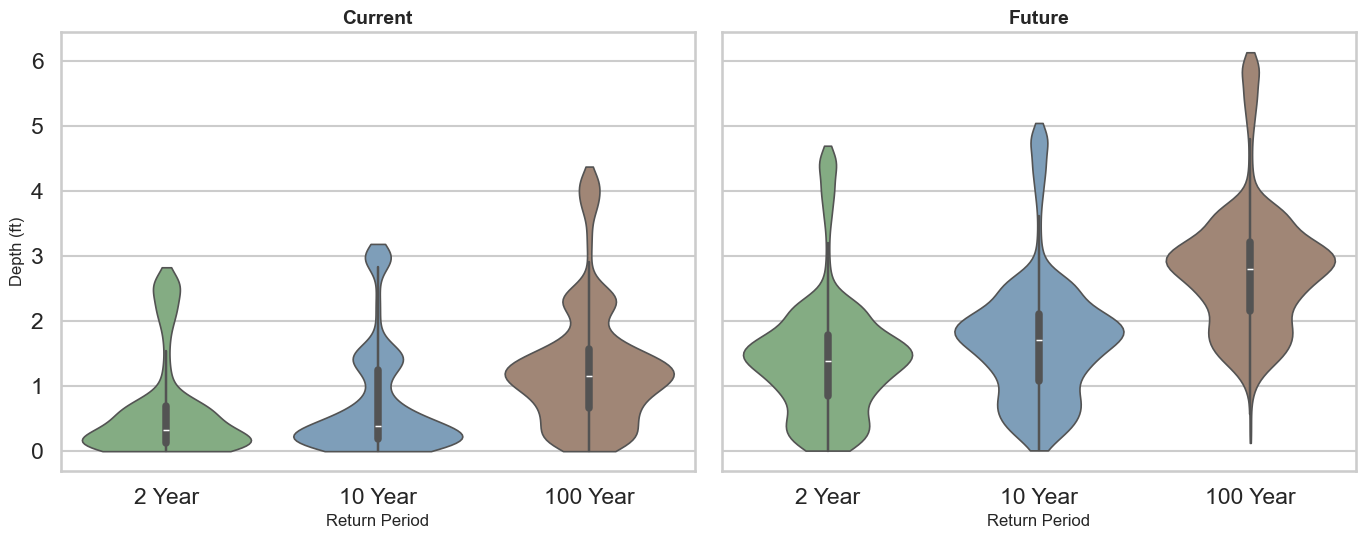

In [ ]:

palette = {
    "2 Year": "#7db37c",
    "10 Year": "#749fc3",
    "100 Year": "#a7846f",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, condition in zip(axes, ["Current", "Future"]):
    subset = df[df["Condition"] == condition].copy()

    sns.violinplot(
        data=subset,
        x="ReturnPeriod",
        y="Depth_ft",
        order=["2 Year", "10 Year", "100 Year"],
        palette=palette,
        inner="box",
        cut=0,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title(condition, fontsize=14, fontweight="bold")
    ax.set_xlabel("Return Period", fontsize=12)
    ax.set_ylabel("Depth (ft)" if condition == "Current" else "", fontsize=12)
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("")
plt.tight_layout()
plt.show()

C:\Users\dveronez\AppData\Local\Temp\ipykernel_4868\4041004010.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\dveronez\AppData\Local\Temp\ipykernel_4868\4041004010.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


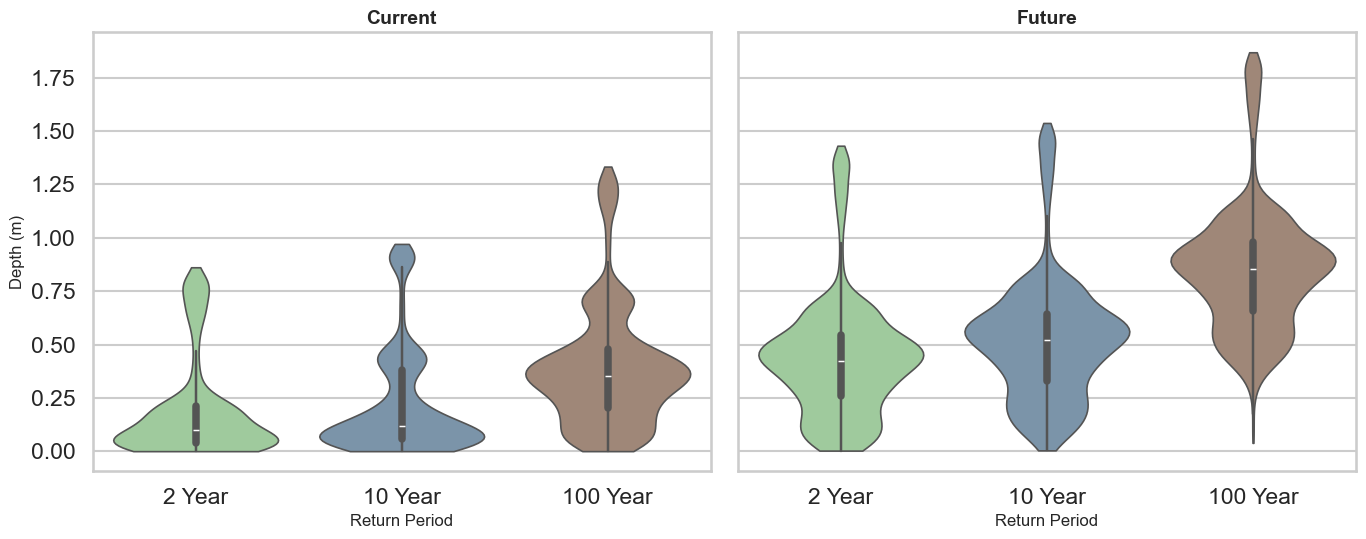

In [16]:
# Convert depth to meters
df["Depth_m"] = df["Depth_ft"] * 0.3048

palette = {
    "2 Year": "#98D196",
    "10 Year": "#7495b0",
    "100 Year": "#a58572",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, condition in zip(axes, ["Current", "Future"]):
    subset = df[df["Condition"] == condition].copy()

    sns.violinplot(
        data=subset,
        x="ReturnPeriod",
        y="Depth_m",
        order=["2 Year", "10 Year", "100 Year"],
        palette=palette,
        inner="box",
        cut=0,
        linewidth=1.2,
        ax=ax
    )

    ax.set_title(condition, fontsize=14, fontweight="bold")
    ax.set_xlabel("Return Period", fontsize=12)
    ax.set_ylabel("Depth (m)" if condition == "Current" else "", fontsize=12)
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("")
plt.tight_layout()
plt.show()

## 8. Optional alternate figure: single-panel violin plot

This version keeps all scenarios in one axis. It is useful for quick comparison, but the two-panel figure is usually cleaner for a paper.

C:\Users\dveronez\AppData\Local\Temp\ipykernel_4868\1451973175.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


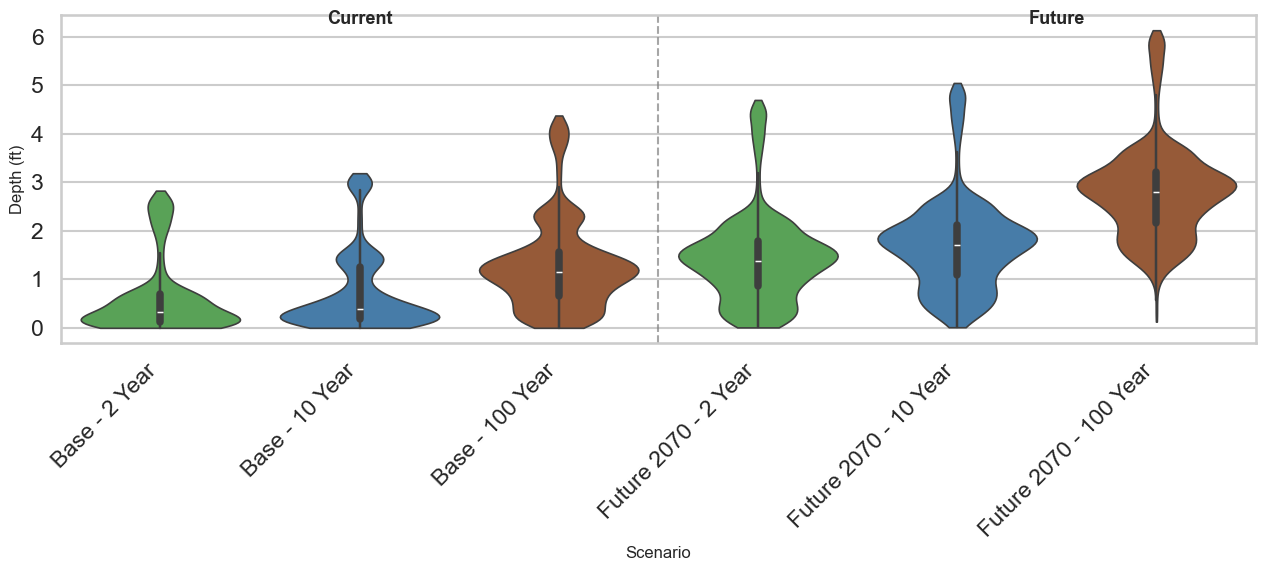

In [8]:
single_palette = {
    "Base - 2 Year": "#4daf4a",
    "Base - 10 Year": "#377eb8",
    "Base - 100 Year": "#a65628",
    "Future 2070 - 2 Year": "#4daf4a",
    "Future 2070 - 10 Year": "#377eb8",
    "Future 2070 - 100 Year": "#a65628",
}

plt.figure(figsize=(13, 6))
ax = sns.violinplot(
    data=df,
    x="Scenario",
    y="Depth_ft",
    order=plot_order,
    palette=single_palette,
    inner="box",
    cut=0,
    linewidth=1.2
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Scenario", fontsize=12)
plt.ylabel("Depth (ft)", fontsize=12)

# Optional visual separator
plt.axvline(x=2.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)

# Group labels
ymax = ax.get_ylim()[1]
plt.text(1.0, ymax * 0.96, "Current", ha="center", va="bottom", fontsize=13, fontweight="bold")
plt.text(4.5, ymax * 0.96, "Future", ha="center", va="bottom", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## 9. Save outputs

Uncomment the lines below when you are ready to export the table and figure files.


In [ ]:
# Save the long-format depth table
# df.to_csv(os.path.join(output_folder, "cypress_park_depth_values_long.csv"), index=False)

# Save the summary statistics table
# summary_df.to_csv(os.path.join(output_folder, "cypress_park_depth_summary.csv"), index=False)

# To save the recommended two-panel figure, rerun the plotting cell above and then use:
# fig.savefig(os.path.join(output_folder, "violin_depth_current_future_panels.png"), dpi=300, bbox_inches="tight")

# To save the single-panel figure, rerun that plotting cell and then use:
# plt.savefig(os.path.join(output_folder, "violin_depth_single_panel.png"), dpi=300, bbox_inches="tight")

## 10. Manuscript 

**Methods sentence**

Maximum flood depth values (ft) were extracted from raster cells located within the Cypress Park boundary polygon using raster masking. Cells outside the polygon and NoData cells were excluded, and flooded cells were defined as depths greater than 0.001 ft. The resulting cell-level depth distributions were summarized using violin plots with internal boxplots for each scenario.

**Figure caption draft**

Distribution of maximum flood depth within Cypress Park under current and future conditions for the 2-year, 10-year, and 100-year events. Violin widths represent the density of raster-cell depth values, while embedded boxplots show the median and interquartile range. Only flooded cells with depth greater than 0.001 ft were included.
